[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Exploring MLPs with toy data

In this notebook we use toy data sets in order to better understand how multilayer perceptrons solve classification problems.

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG
from matplotlib import pyplot as plt

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader,TensorDataset

In [2]:
# if you have a GPU we could enable it
# mps is the pytorch device that supports GPU computations on MacOS

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
# these datasets are tiny, so the CPU is actually faster here (no host<->device
# transfer overhead); we override the auto-detected device on purpose.
device = "cpu"
print(f"Using {device} device")

Using cpu device


## MLPs on the XOR dataset

In [3]:
# Generate Synthetic XOR Data
# Inputs and their corresponding outputs:
# (0, 0) -> 0
# (0, 1) -> 1
# (1, 0) -> 1
# (1, 1) -> 0

def xor_data(samples_per_point=100, noise_std=0.1, seed=42):
    rng = np.random.default_rng(seed)   # local generator -> reproducible, no global state
    # Create data points around the four XOR points
    X_00 = rng.standard_normal((samples_per_point, 2)) * noise_std + np.array([0.0, 0.0])
    y_00 = np.zeros(samples_per_point)
    X_01 = rng.standard_normal((samples_per_point, 2)) * noise_std + np.array([0.0, 1.0])
    y_01 = np.ones(samples_per_point)
    X_10 = rng.standard_normal((samples_per_point, 2)) * noise_std + np.array([1.0, 0.0])
    y_10 = np.ones(samples_per_point)
    X_11 = rng.standard_normal((samples_per_point, 2)) * noise_std + np.array([1.0, 1.0])
    y_11 = np.zeros(samples_per_point)

    # combine the data
    X = np.vstack((X_00, X_01, X_10, X_11))
    y = np.hstack((y_00, y_01, y_10, y_11))

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    return X, y

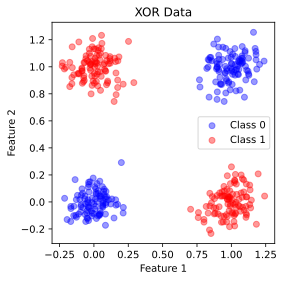

In [4]:
X,y = xor_data()

plt.figure(figsize=(4, 4))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Class 0', alpha=0.4)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Class 1', alpha=0.4)
plt.title('XOR Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend();

In [5]:
def loader(X, y, batch_size=32, seed=0):
    # a seeded generator makes the shuffling deterministic, so training outcomes
    # depend only on the seed we pass (and not on any earlier use of the RNG)
    g = torch.Generator()
    g.manual_seed(seed)
    dataset = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=g)

In [6]:
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)   # hidden layer
        self.fc2 = nn.Linear(2, 2)   # output layer
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

In [7]:
def train_epoch(model, train_loader, loss_fn, optimizer):
    model.train()
    total_loss = 0.0   # sum of per-example losses
    total_examples = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.numel()
        total_examples += y.numel()
    return total_loss / total_examples


def correctly_classified(y_hat, y):
    """Return the number of correct predictions in a batch."""
    if len(y_hat.shape) > 1:
        y_hat = y_hat.argmax(dim=1)
    return (y_hat == y).type(torch.float32).sum().item()


def evaluate(model, loss_fn, data_loader):
    model.eval()
    total_loss = 0.0
    correct = 0.0
    total = 0
    with torch.no_grad():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            total_loss += loss_fn(y_pred, y).item() * y.numel()
            correct += correctly_classified(y_pred, y)
            total += y.numel()
    return correct / total, total_loss / total

### Initialization matters

A network with only two hidden units is just barely large enough to represent the XOR problem, and
whether SGD actually *finds* a solution depends on the initial weights. Below we train
the identical architecture from three random initializations:

* `init_seed = 0` converges to ~100% accuracy.
* `init_seed = 4` never trains, because both hidden units are *dead* from the start.
* `init_seed = 11` trains, but gets stuck at 75% accuracy.

In [8]:
# reuse the SAME X, y generated (and plotted) above.
# The 2-unit XORNet only converges for *some* weight initializations, so we
# control the initialization explicitly with a seed. Try changing init_seed!
init_seed = 0   # seed 0 -> converges to ~100%; seeds 4 and 11 fail (see below)
torch.manual_seed(init_seed)

train_loader = loader(X, y, batch_size=32, seed=init_seed)
model = XORNet()
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

In [9]:
epochs = 130
# per-epoch training metrics (evaluated on the training set)
train_losses, train_accs = [], []

for epoch in range(epochs):
    train_epoch(model, train_loader, loss_fn, optimizer)
    # re-evaluate on the training data to log loss/accuracy for this epoch
    epoch_acc, epoch_loss = evaluate(model, loss_fn, train_loader)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    if epoch % 10 == 0:
        print("epoch", epoch + 1)
        print("loss", epoch_loss, "accuracy: ", epoch_acc)

epoch 1
loss 0.6795977163314819 accuracy:  0.7125
epoch 11
loss 0.5693390560150147 accuracy:  0.735
epoch 21
loss 0.36445247173309325 accuracy:  0.995
epoch 31
loss 0.16929566442966462 accuracy:  0.9975
epoch 41
loss 0.09710577666759491 accuracy:  0.9975
epoch 51
loss 0.06582744136452674 accuracy:  0.9975
epoch 61
loss 0.04947723135352135 accuracy:  0.9975
epoch 71
loss 0.03966252088546753 accuracy:  0.9975
epoch 81
loss 0.033145844638347625 accuracy:  0.9975
epoch 91
loss 0.02856674887239933 accuracy:  0.9975
epoch 101
loss 0.02516718603670597 accuracy:  0.9975
epoch 111
loss 0.022546556293964386 accuracy:  0.9975
epoch 121
loss 0.020475655719637872 accuracy:  0.9975


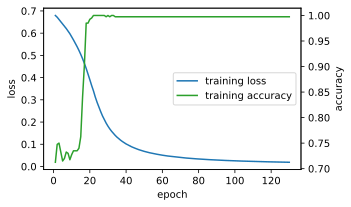

In [10]:
from matplotlib import pyplot as plt

epochs_axis = range(1, len(train_losses) + 1)
fig, ax_loss = plt.subplots(figsize=(5, 3))

l1 = ax_loss.plot(epochs_axis, train_losses, label='training loss')
ax_loss.set_xlabel('epoch')
ax_loss.set_ylabel('loss')

ax_acc = ax_loss.twinx()
l2 = ax_acc.plot(epochs_axis, train_accs, label='training accuracy', color='tab:green')
ax_acc.set_ylabel('accuracy')

lines = l1 + l2
ax_loss.legend(lines, [ln.get_label() for ln in lines], loc='center right')
plt.tight_layout();

### Looking at the activations

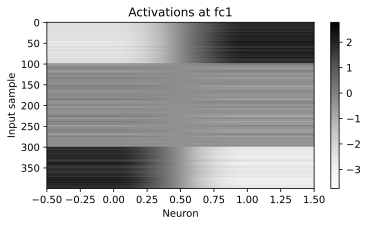

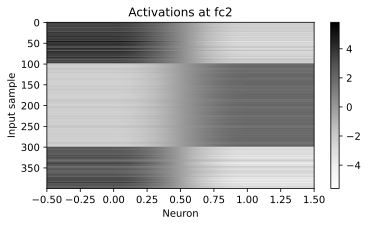

In [11]:
activations = {}
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Register hooks, then run a forward pass to capture activations
model.fc1.register_forward_hook(get_activation("fc1"))
model.fc2.register_forward_hook(get_activation("fc2"))

X_t = torch.tensor(X).to(device)
_ = model(X_t)

# Heatmap of the activations at each layer
for layer, act in activations.items():
    plt.figure(figsize=(6, 3))
    plt.title(f"Activations at {layer}")
    plt.imshow(act, aspect="auto", cmap="Greys")
    plt.colorbar()
    plt.xlabel("Neuron")
    plt.ylabel("Input sample")

The two hidden units define a new 2D representation of each input. Note that the hook on
`fc1` captures its output **before** the ReLU (the hook fires on the `Linear` layer's
output). Let's plot the data in that pre-activation hidden space:

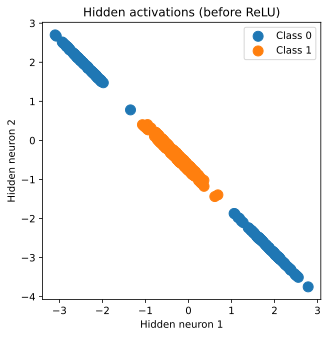

In [12]:
# fc1 output is captured BEFORE relu (hook is on the Linear layer)
hidden_pre = activations["fc1"]

plt.figure(figsize=(5, 5))
for cls in [0, 1]:
    idx = (y == cls)
    plt.scatter(hidden_pre[idx, 0], hidden_pre[idx, 1], label=f"Class {cls}", s=100)
plt.xlabel("Hidden neuron 1")
plt.ylabel("Hidden neuron 2")
plt.title("Hidden activations (before ReLU)")
plt.legend();

Next we apply the ReLU. This is the key step: ReLU sets negative coordinates to zero, which
collapses part of the hidden space onto the axes and the origin. After this collapse the two classes
are **linearly separable**.

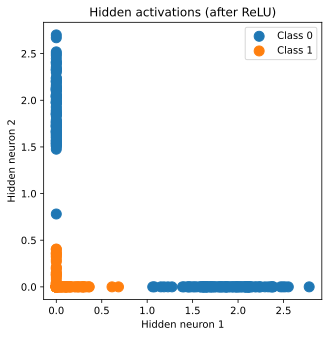

In [13]:
import torch.nn.functional as F
hidden_post = F.relu(activations["fc1"])

plt.figure(figsize=(5, 5))
for cls in [0, 1]:
    idx = (y == cls)
    plt.scatter(hidden_post[idx, 0], hidden_post[idx, 1], label=f"Class {cls}", s=100)
plt.xlabel("Hidden neuron 1")
plt.ylabel("Hidden neuron 2")
plt.title("Hidden activations (after ReLU)")
plt.legend();

Finally, let's visualize the decision boundary of the trained network in the
original input space:

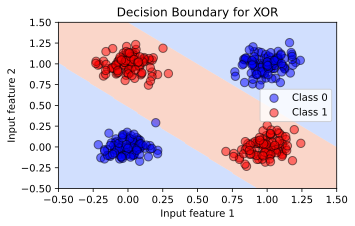

In [14]:
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200),
                     np.linspace(-0.5, 1.5, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

with torch.no_grad():
    logits = model(grid)
    Z = torch.argmax(logits, dim=1).reshape(xx.shape)

plt.figure(figsize=(5, 3))
plt.contourf(xx, yy, Z, alpha=0.4, levels=[-0.5, 0.5, 1.5], cmap="coolwarm")

colors = ["blue", "red"]
for cls in [0, 1]:
    idx = (y == cls)
    plt.scatter(X[idx, 0], X[idx, 1],
                c=colors[cls], label=f"Class {cls}", s=70, alpha=0.5, edgecolor='k')
plt.title("Decision Boundary for XOR")
plt.xlabel("Input feature 1")
plt.ylabel("Input feature 2")
plt.legend();

Each hidden unit defines a line $\mathbf{w}_i^\top \mathbf{x} + b_i = 0$ in the input space.
On one side of the line the unit is active and outputs $\mathbf{w}_i^\top \mathbf{x} + b_i$; on the other side it outputs zero.
Let's draw each unit's line and shade its active side:

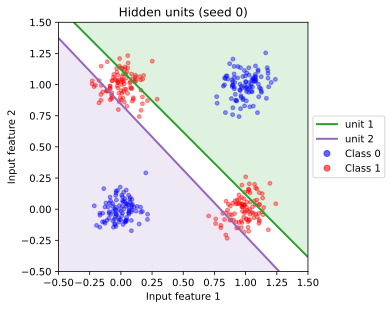

In [15]:
from matplotlib.lines import Line2D

def plot_hidden_lines(model, X, y, title, lim=(-0.5, 1.5)):
    """Draw the line w_i . x + b_i = 0 of each hidden unit and shade its active side."""
    W = model.fc1.weight.detach().cpu().numpy()
    b = model.fc1.bias.detach().cpu().numpy()
    xx, yy = np.meshgrid(np.linspace(*lim, 200), np.linspace(*lim, 200))
    unit_colors = ['tab:green', 'tab:purple', 'tab:orange', 'tab:brown']
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    for i in range(len(b)):
        z = W[i, 0] * xx + W[i, 1] * yy + b[i]
        color = unit_colors[i % len(unit_colors)]
        ax.contourf(xx, yy, z, levels=[0, np.inf], colors=[color], alpha=0.15)
        ax.contour(xx, yy, z, levels=[0], colors=[color], linewidths=2)
    for cls, c in zip([0, 1], ['blue', 'red']):
        ax.scatter(X[y == cls, 0], X[y == cls, 1], c=c, s=15, alpha=0.4)
    handles = [Line2D([], [], color=unit_colors[i % len(unit_colors)], lw=2, label=f'unit {i + 1}')
               for i in range(len(b))]
    handles += [Line2D([], [], marker='o', ls='', color=c, alpha=0.6, label=f'Class {cls}')
                for cls, c in zip([0, 1], ['blue', 'red'])]
    ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1, 0.5))
    ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect('equal')
    ax.set_xlabel('Input feature 1'); ax.set_ylabel('Input feature 2')
    ax.set_title(title)

plot_hidden_lines(model, X, y, 'Hidden units (seed 0)')

The two lines are nearly parallel. One unit is active only near (1,1) and the other only near (0,0).
Both class-1 clusters lie in or near the band between the lines, where both units output zero or close to it, so ReLU maps
class 1 to (or near) the origin of the hidden space. That is why the classes were separable in the post-ReLU plot above.

#### Dead hidden units

Now let's retrain the same architecture, changing only the initialization seed to 4.
The loss stays at $\ln 2 \approx 0.693$ from the start, which is the loss of a classifier
that predicts 50/50 for every input.

In [16]:
# identical setup, only the init seed changes
torch.manual_seed(4)   # a seed that gets trapped near 50% accuracy

train_loader = loader(X, y, batch_size=32, seed=4)
model_bad = XORNet().to(device)
optimizer = torch.optim.SGD(model_bad.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

train_losses, train_accs = [], []
for epoch in range(130):
    train_epoch(model_bad, train_loader, loss_fn, optimizer)
    epoch_acc, epoch_loss = evaluate(model_bad, loss_fn, train_loader)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    if epoch % 10 == 0:
        print("epoch", epoch + 1, "loss", round(epoch_loss, 4), "accuracy:", epoch_acc)

epoch 1 loss 0.6938 accuracy: 0.5
epoch 11 loss 0.6932 accuracy: 0.5
epoch 21 loss 0.6931 accuracy: 0.5
epoch 31 loss 0.6932 accuracy: 0.5
epoch 41 loss 0.6932 accuracy: 0.5
epoch 51 loss 0.6932 accuracy: 0.5
epoch 61 loss 0.6932 accuracy: 0.5
epoch 71 loss 0.6932 accuracy: 0.5
epoch 81 loss 0.6932 accuracy: 0.5
epoch 91 loss 0.6932 accuracy: 0.5
epoch 101 loss 0.6932 accuracy: 0.5
epoch 111 loss 0.6932 accuracy: 0.5
epoch 121 loss 0.6931 accuracy: 0.5


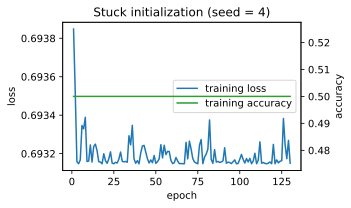

In [17]:
epochs_axis = range(1, len(train_losses) + 1)
fig, ax_loss = plt.subplots(figsize=(5, 3))
l1 = ax_loss.plot(epochs_axis, train_losses, label='training loss')
ax_loss.set_xlabel('epoch'); ax_loss.set_ylabel('loss')
ax_acc = ax_loss.twinx()
l2 = ax_acc.plot(epochs_axis, train_accs, label='training accuracy', color='tab:green')
ax_acc.set_ylabel('accuracy')
lines = l1 + l2
ax_loss.legend(lines, [ln.get_label() for ln in lines], loc='center right')
plt.title("Stuck initialization (seed = 4)")
plt.tight_layout();

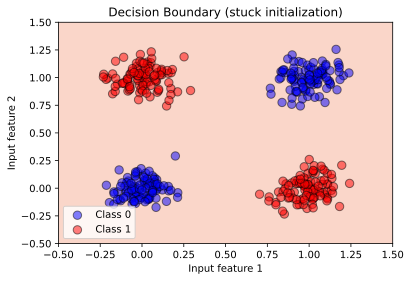

In [18]:
# decision boundary for the stuck network
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    Z = torch.argmax(model_bad(grid), dim=1).reshape(xx.shape)

plt.figure(figsize=(6, 4))
plt.contourf(xx, yy, Z, alpha=0.4, levels=[-0.5, 0.5, 1.5], cmap="coolwarm")
colors = ["blue", "red"]
for cls in [0, 1]:
    idx = (y == cls)
    plt.scatter(X[idx, 0], X[idx, 1], c=colors[cls], label=f"Class {cls}",
                s=70, alpha=0.5, edgecolor='k')
plt.title("Decision Boundary (stuck initialization)")
plt.xlabel("Input feature 1"); plt.ylabel("Input feature 2")
plt.legend();

Why doesn't it train? Let's check on how many training points each hidden unit is active,
and compute the gradient of the loss with respect to the first-layer weights:

In [19]:
X_t, y_t = torch.tensor(X), torch.tensor(y)
with torch.no_grad():
    active = (model_bad.fc1(X_t) > 0).float().mean(dim=0)
print("fraction of points on each unit's active side:", active.tolist())

model_bad.zero_grad()
loss_fn(model_bad(X_t), y_t).backward()
print("norm of the gradient for fc1 weights:", model_bad.fc1.weight.grad.norm().item())

fraction of points on each unit's active side: [0.0, 0.0]
norm of the gradient for fc1 weights: 0.0


Both hidden units are **dead**: every training point lies on the inactive side of both lines
(the lines lie outside the region containing the data), so both units output zero for every input.
The output layer sees the same hidden vector (0, 0) for every example, and the best it can do is predict 50/50.
The derivative of ReLU is zero on the inactive side, so no gradient reaches `fc1` and its weights never change.
This is not a local minimum: the loss is flat in every direction that would move the hidden units, so gradient descent has nothing to follow.
This was already the case at initialization; it is not something training did.

Dead units are one reason wider networks train more reliably: it is unlikely that *every* unit starts out dead.

#### A network that gets stuck

A network can also fail with all of its units alive. With `init_seed = 11`, training makes progress, but accuracy levels off at 75%:

In [20]:
torch.manual_seed(11)
train_loader = loader(X, y, batch_size=32, seed=11)
model_stuck = XORNet().to(device)
optimizer = torch.optim.SGD(model_stuck.parameters(), lr=0.1)

for epoch in range(130):
    train_epoch(model_stuck, train_loader, loss_fn, optimizer)
    if epoch % 20 == 0 or epoch == 129:
        epoch_acc, epoch_loss = evaluate(model_stuck, loss_fn, train_loader)
        print("epoch", epoch + 1, "loss", round(epoch_loss, 4), "accuracy:", epoch_acc)

epoch 1 loss 0.654 accuracy: 0.5
epoch 21 loss 0.4777 accuracy: 0.7475
epoch 41 loss 0.3827 accuracy: 0.7475
epoch 61 loss 0.3609 accuracy: 0.7475
epoch 81 loss 0.3549 accuracy: 0.7475
epoch 101 loss 0.3523 accuracy: 0.7475
epoch 121 loss 0.3508 accuracy: 0.75
epoch 130 loss 0.3504 accuracy: 0.75


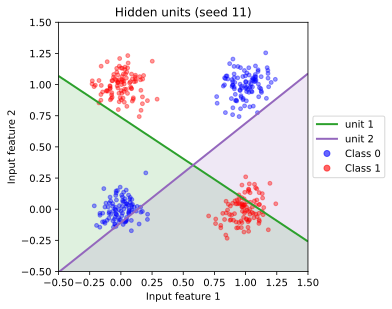

In [21]:
plot_hidden_lines(model_stuck, X, y, 'Hidden units (seed 11)')

Both units are active on part of the data, so neither is dead. Let's look at where each XOR cluster lands in the hidden space after the ReLU
(the data contains 100 points per cluster, in the order (0,0), (0,1), (1,0), (1,1)):

In [22]:
with torch.no_grad():
    H = torch.relu(model_stuck.fc1(X_t))
for k, corner in enumerate([(0, 0), (0, 1), (1, 0), (1, 1)]):
    cluster = slice(100 * k, 100 * (k + 1))
    print(f"cluster {corner}, class {y[cluster][0]}: mean hidden vector {H[cluster].mean(dim=0).numpy().round(2)}")

cluster (0, 0), class 0: mean hidden vector [1.38 0.02]
cluster (0, 1), class 1: mean hidden vector [0. 0.]
cluster (1, 0), class 1: mean hidden vector [0.2  1.59]
cluster (1, 1), class 0: mean hidden vector [0. 0.]


Unit 1 is active on the (0,0) cluster (and weakly on (1,0)), and unit 2 is active on the (1,0) cluster. The clusters at (0,1) (class 1) and (1,1) (class 0)
are on the inactive side of both lines, so ReLU maps both of them to the origin.
Once points from two classes are mapped to the same hidden vector, no output layer can separate them, which caps accuracy at 75%.
SGD does not escape this configuration: the accuracy is still 75% after 1,000 epochs.

The two failures are different:

* **Dead units:** the units output zero on all the data, so there is no gradient and training never starts.
* **Stuck:** the units work and the gradient is not zero, but SGD has settled on lines that send points from different classes to the same hidden vector.

## MLPs on circle data

The following is another example that illustrates how the ability of MLPs to classify a dataset depends on the number of hidden neurons.

In [23]:
def circle_data(samples_per_class=150, seed=42):
    rng = np.random.default_rng(seed)   # local generator -> reproducible
    r1 = 0.5
    r2 = np.sqrt(2 * r1**2)
    r3 = np.sqrt(r1**2 + r2**2)

    X_circle = []
    y_circle = []
    for i in range(samples_per_class):
        # Inner disk (class 0)
        vec = rng.uniform(-1, 1, 2)
        while np.linalg.norm(vec) > r1:
            vec = rng.uniform(-1, 1, 2)
        X_circle.append(vec)
        y_circle.append(0)

        # Surrounding annulus (class 1)
        vec = rng.uniform(-1, 1, 2)
        while np.linalg.norm(vec) < r2 or np.linalg.norm(vec) > r3:
            vec = rng.uniform(-1, 1, 2)
        X_circle.append(vec)
        y_circle.append(1)

    X_circle = np.array(X_circle).astype('float32')
    y_circle = np.array(y_circle)
    return X_circle, y_circle

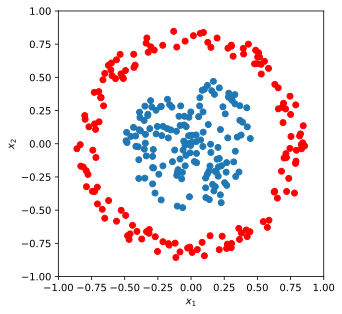

In [24]:
X_circle, y_circle = circle_data()
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(X_circle[y_circle==0, 0], X_circle[y_circle==0, 1])
ax.scatter(X_circle[y_circle==1, 0], X_circle[y_circle==1, 1], c='r')
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_aspect('equal', 'box');

In [25]:
class CircleNet(nn.Module):
    def __init__(self,num_hidden=8):
        super().__init__()
        self.fc1 = nn.Linear(2, num_hidden)   # hidden layer
        self.fc2 = nn.Linear(num_hidden, 2)   # output layer
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

As with XOR, a 4-unit `CircleNet` does not always converge. We again fix the
initialization with `init_seed` so the result is reproducible (seed 3 converges; seed 4 stalls). Increasing the number of hidden units to `num_hidden=8` makes convergence far more reliable, which is the central lesson of this notebook: **more neurons buy robustness to initialization, not just capacity.**

In [26]:
# reuse the SAME circle data generated (and plotted) above.
# With only 4 hidden units the CircleNet is again initialization-sensitive.
init_seed = 3   # seed 3 -> converges to ~100%; seed 4 -> stalls around 78%
torch.manual_seed(init_seed)

train_loader = loader(X_circle, y_circle, batch_size=32, seed=init_seed)
model = CircleNet(num_hidden=4)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

In [27]:
epochs = 150
# per-epoch training metrics (evaluated on the training set)
train_losses, train_accs = [], []

for epoch in range(epochs):
    train_epoch(model, train_loader, loss_fn, optimizer)
    # re-evaluate on the training data to log loss/accuracy for this epoch
    epoch_acc, epoch_loss = evaluate(model, loss_fn, train_loader)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    if epoch % 10 == 0:
        print("epoch", epoch + 1)
        print("loss", epoch_loss, "accuracy: ", epoch_acc)

epoch 1
loss 0.6740184013048808 accuracy:  0.5966666666666667
epoch 11
loss 0.6181645766894023 accuracy:  0.7633333333333333
epoch 21
loss 0.5396699786186219 accuracy:  0.7833333333333333
epoch 31
loss 0.46565600236256915 accuracy:  0.8
epoch 41
loss 0.3881694261233012 accuracy:  0.8933333333333333
epoch 51
loss 0.2990685272216797 accuracy:  0.9566666666666667
epoch 61
loss 0.23172312517960866 accuracy:  0.98
epoch 71
loss 0.1890159261226654 accuracy:  0.9933333333333333
epoch 81
loss 0.1588657412926356 accuracy:  1.0
epoch 91
loss 0.13738212923208873 accuracy:  1.0
epoch 101
loss 0.12094248702128728 accuracy:  1.0
epoch 111
loss 0.10808822224537531 accuracy:  1.0
epoch 121
loss 0.09749778191248576 accuracy:  1.0
epoch 131
loss 0.08852408985296885 accuracy:  1.0
epoch 141
loss 0.08101207494735718 accuracy:  1.0


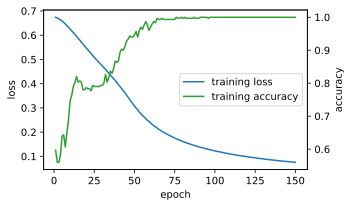

In [28]:
from matplotlib import pyplot as plt

epochs_axis = range(1, len(train_losses) + 1)
fig, ax_loss = plt.subplots(figsize=(5, 3))

l1 = ax_loss.plot(epochs_axis, train_losses, label='training loss')
ax_loss.set_xlabel('epoch')
ax_loss.set_ylabel('loss')

ax_acc = ax_loss.twinx()
l2 = ax_acc.plot(epochs_axis, train_accs, label='training accuracy', color='tab:green')
ax_acc.set_ylabel('accuracy')

lines = l1 + l2
ax_loss.legend(lines, [ln.get_label() for ln in lines], loc='center right')
plt.tight_layout();

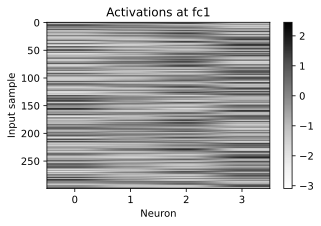

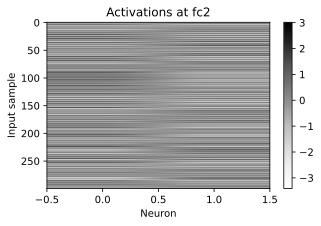

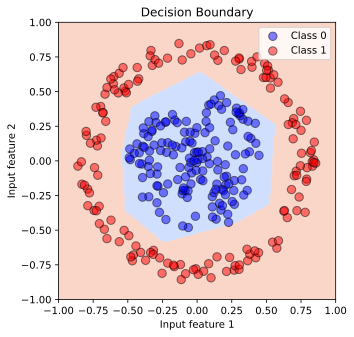

In [29]:
activations = {}
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Register hooks, then run a forward pass to capture activations
model.fc1.register_forward_hook(get_activation("fc1"))
model.fc2.register_forward_hook(get_activation("fc2"))

X_t = torch.tensor(X_circle).to(device)
_ = model(X_t)

# Heatmap visualization of the activations
for layer, act in activations.items():
    plt.figure(figsize=(5, 3))
    plt.title(f"Activations at {layer}")
    plt.imshow(act, aspect="auto", cmap="Greys")
    plt.colorbar()
    plt.xlabel("Neuron")
    plt.ylabel("Input sample")

# Decision boundary over a grid
xx, yy = np.meshgrid(np.linspace(-1, 1, 200),
                     np.linspace(-1, 1, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

with torch.no_grad():
    logits = model(grid)
    Z = torch.argmax(logits, dim=1).reshape(xx.shape)

plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, Z, alpha=0.4, levels=[-0.5, 0.5, 1.5], cmap="coolwarm")

# overlay the SAME circle data the model was trained on
colors = ["blue", "red"]
for cls in [0, 1]:
    idx = (y_circle == cls)
    plt.scatter(X_circle[idx, 0], X_circle[idx, 1],
                c=colors[cls], label=f"Class {cls}", s=70, alpha=0.5, edgecolor='k')

plt.title("Decision Boundary")
plt.xlabel("Input feature 1")
plt.ylabel("Input feature 2")
plt.gca().set_aspect('equal', 'box')   # radial data -> keep circles circular
plt.legend();